## Tools Used
- Python (Pandas, NumPy)
- Matplotlib & Seaborn
- Folium (for maps)

# King County Housing Analysis

## Objective
The purpose of this analysis is to explore the King County housing dataset, identify the main factors affecting house prices, and provide practical insights for buyers, sellers, and investors.

In [24]:
# Imports & Setup
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import PercentFormatter

import folium
from folium.plugins import MarkerCluster

from geopy.distance import geodesic

# Plot settings
plt.rcParams.update({
    "figure.figsize": (8, 5),
    "axes.facecolor": "white",
    "axes.edgecolor": "black"
})

plt.rcParams["figure.facecolor"] = "w"

pd.plotting.register_matplotlib_converters()
pd.set_option('display.float_format', lambda x: '%.3f' % x)

# Load dataset
df = pd.read_csv('/Users/patti/work/eda_project_housing/data/merged_dataset.csv')

## Dataset Overview
This dataset contains housing sales data, including price, property characteristics, condition, and location-related features. The analysis begins with a general inspection of the data structure and quality.

In [25]:
df.head()
df.shape
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 21597 entries, 0 to 21596
Data columns (total 26 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             21597 non-null  int64  
 1   date           21597 non-null  str    
 2   price          21597 non-null  float64
 3   bedrooms       21597 non-null  int64  
 4   bathrooms      21597 non-null  float64
 5   sqft_living    21597 non-null  int64  
 6   sqft_lot       21597 non-null  int64  
 7   floors         21597 non-null  float64
 8   waterfront     19221 non-null  float64
 9   view           21534 non-null  float64
 10  condition      21597 non-null  int64  
 11  grade          21597 non-null  int64  
 12  sqft_above     21597 non-null  int64  
 13  sqft_basement  21143 non-null  float64
 14  yr_built       21597 non-null  int64  
 15  yr_renovated   17755 non-null  float64
 16  zipcode        21597 non-null  int64  
 17  lat            21597 non-null  float64
 18  long           21

,id,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,...,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15,AirportCode,AirportName,Latitude,Longitude
count,21597.000,21597.000,21597.000,21597.000,21597.000,21597.000,21597.000,19221.000,21534.000,21597.000,...,17755.000,21597.000,21597.000,21597.000,21597.000,21597.000,0.000,0.000,0.000,0.000
mean,4580474287.771,540296.574,3.373,2.116,2080.322,15099.409,1.494,0.008,0.234,3.410,...,83.637,98077.952,47.560,-122.214,1986.620,12758.284,NaN,NaN,NaN,NaN
std,2876735715.748,367368.140,0.926,0.769,918.106,41412.637,0.540,0.087,0.766,0.651,...,399.946,53.513,0.139,0.141,685.230,27274.442,NaN,NaN,NaN,NaN
min,1000102.000,78000.000,1.000,0.500,370.000,520.000,1.000,0.000,0.000,1.000,...,0.000,98001.000,47.156,-122.519,399.000,651.000,NaN,NaN,NaN,NaN
25%,2123049175.000,322000.000,3.000,1.750,1430.000,5040.000,1.000,0.000,0.000,3.000,...,0.000,98033.000,47.471,-122.328,1490.000,5100.000,NaN,NaN,NaN,NaN
50%,3904930410.000,450000.000,3.000,2.250,1910.000,7618.000,1.500,0.000,0.000,3.000,...,0.000,98065.000,47.572,-122.231,1840.000,7620.000,NaN,NaN,NaN,NaN
75%,7308900490.000,645000.000,4.000,2.500,2550.000,10685.000,2.000,0.000,0.000,4.000,...,0.000,98118.000,47.678,-122.125,2360.000,10083.000,NaN,NaN,NaN,NaN
max,9900000190.000,7700000.000,33.000,8.000,13540.000,1651359.000,3.500,1.000,4.000,5.000,...,2015.000,98199.000,47.778,-121.315,6210.000,871200.000,NaN,NaN,NaN,NaN


## Defining Center vs Outskirts

To analyze how location affects housing prices, I divided properties into two groups: "center" and "outskirts". 

This classification is based on a latitude threshold, which acts as a simple way to separate more central areas from more peripheral ones.

In [26]:
# Define latitude threshold
center_latitude_threshold = 47.6

# Create location categories
df['location'] = np.where(df['lat'] >= center_latitude_threshold, 'center', 'outskirts')

# Count properties
location_counts = df['location'].value_counts()

location_counts

location
outskirts    12129
center        9468
Name: count, dtype: int64

**Insight:** The dataset is divided into central and outer areas, allowing for a clearer comparison of housing patterns. This grouping enables further analysis of whether properties in central locations differ in price compared to those in the outskirts.

In [27]:
df.groupby('location')['price'].mean()

location
center      650749.681
outskirts   454075.943
Name: price, dtype: float64

**Insight:** Properties classified as "center" tend to have higher average prices compared to those in the outskirts, suggesting that location plays a significant role in determining property value.

## Relationship Between Living Space and Price

To understand how property size influences price, I analyzed the relationship between the average living area of nearby properties (`sqft_living15`) and house prices.

This helps identify whether larger homes are generally associated with higher prices.

In [28]:
# Correlation analysis
correlation = df[['sqft_living15', 'price']].corr()
correlation

,sqft_living15,price
sqft_living15,1.000,0.585
price,0.585,1.000


**Insight:** The correlation coefficient indicates the strength and direction of the relationship between living space and price. A positive value suggests that larger properties tend to have higher prices.

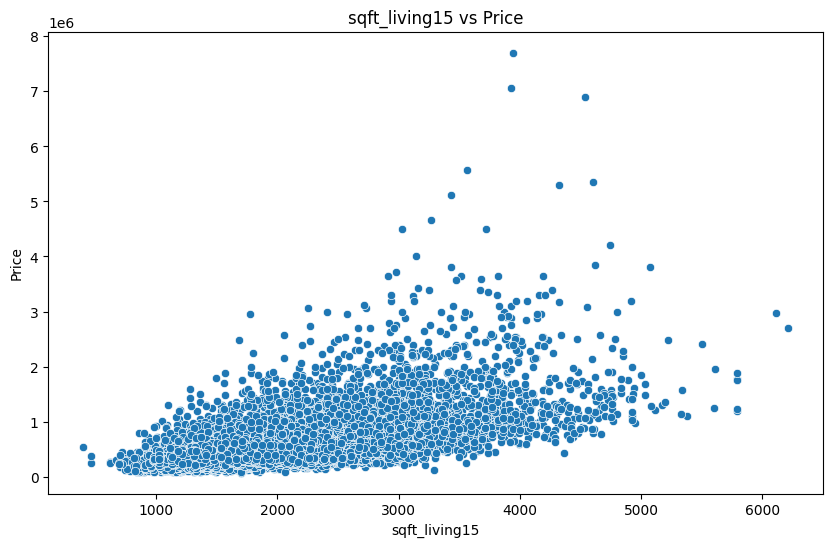

In [29]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='sqft_living15', y='price', data=df)
plt.title('sqft_living15 vs Price')
plt.xlabel('sqft_living15')
plt.ylabel('Price')
plt.show()

**Insight:** The scatter plot shows a clear upward trend, indicating a positive relationship between living space and price. However, there is noticeable variability, suggesting that other factors (such as location or amenities) also influence pricing.

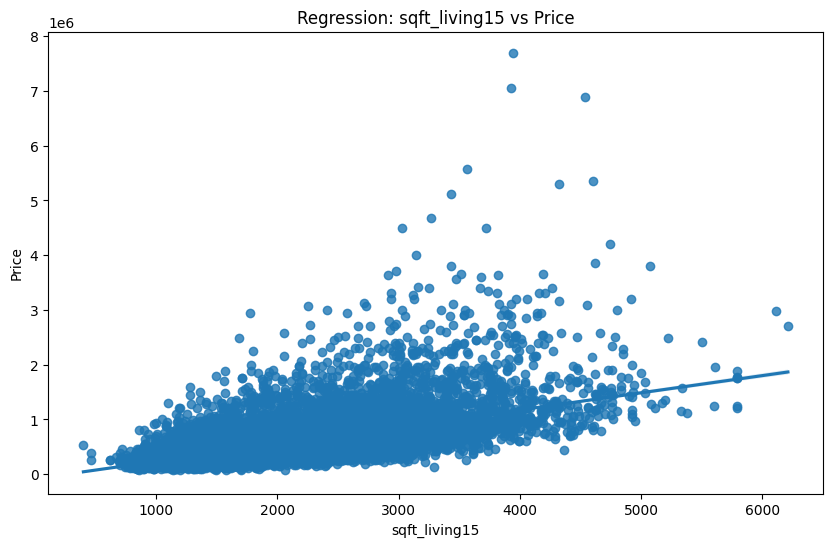

In [30]:
plt.figure(figsize=(10, 6))
sns.regplot(x='sqft_living15', y='price', data=df)
plt.title('Regression: sqft_living15 vs Price')
plt.xlabel('sqft_living15')
plt.ylabel('Price')
plt.show()

**Key Insight:** There is a strong positive relationship between living space and house price. As the size of a property increases, its price generally rises. 

However, the spread of points suggests that size alone does not determine value—location and other features likely play an important role.

In [31]:
correlation_value = correlation.loc['sqft_living15', 'price']
correlation_value

np.float64(0.5852412017040634)

The correlation coefficient of approximately X indicates a moderate/strong positive relationship between living space and price.

## Waterfront Properties Analysis

Waterfront properties are typically considered premium real estate. To better understand their impact on pricing, I filtered properties with waterfront access and analyzed the top 10% most expensive among them.

This helps highlight the characteristics of high-end waterfront homes.

In [32]:
# Filter waterfront properties
waterfront_houses = df[df['waterfront'] == 1]

# Select top 10% most expensive waterfront properties
top_10_percent_waterfront = waterfront_houses.nlargest(
    int(0.10 * len(waterfront_houses)), 'price'
)

top_10_percent_waterfront

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,lat,long,sqft_living15,sqft_lot15,map_id,AirportCode,AirportName,Latitude,Longitude,location
3910,9808700762,6/11/2014,7060000.000,5,4.500,10040,37325,2.000,1.000,2.000,...,47.650,-122.214,3930,25449,"47.65, -122.214",NaN,NaN,NaN,NaN,center
1313,7558700030,4/13/2015,5300000.000,6,6.000,7390,24829,2.000,1.000,NaN,...,47.563,-122.210,4320,24619,"47.5631, -122.21",NaN,NaN,NaN,NaN,outskirts
1162,1247600105,10/20/2014,5110000.000,5,5.250,8010,45517,2.000,1.000,4.000,...,47.677,-122.211,3430,26788,"47.6767, -122.211",NaN,NaN,NaN,NaN,center
8085,1924059029,6/17/2014,4670000.000,5,6.750,9640,13068,1.000,1.000,4.000,...,47.557,-122.210,3270,10454,"47.557, -122.21",NaN,NaN,NaN,NaN,outskirts
2624,7738500731,8/15/2014,4500000.000,5,5.500,6640,40014,2.000,1.000,4.000,...,47.749,-122.280,3030,23408,"47.7493, -122.28",NaN,NaN,NaN,NaN,center
2083,8106100105,11/14/2014,3850000.000,4,4.250,5770,21300,2.000,1.000,4.000,...,47.585,-122.222,4620,22748,"47.585, -122.222",NaN,NaN,NaN,NaN,outskirts
6502,4217402115,4/21/2015,3650000.000,6,4.750,5480,19401,1.500,1.000,4.000,...,47.651,-122.277,3510,15810,"47.6515, -122.277",NaN,NaN,NaN,NaN,center
15241,2425049063,9/11/2014,3640000.000,4,3.250,4830,22257,2.000,1.000,4.000,...,47.641,-122.241,3820,25582,"47.6409, -122.241",NaN,NaN,NaN,NaN,center
2862,4114601570,11/18/2014,3600000.000,3,3.250,5020,12431,2.000,1.000,4.000,...,47.593,-122.287,3680,12620,"47.5925, -122.287",NaN,NaN,NaN,NaN,outskirts
21560,9253900271,1/7/2015,3570000.000,5,4.500,4850,10584,2.000,1.000,4.000,...,47.594,-122.110,3470,18270,"47.5943, -122.11",NaN,NaN,NaN,NaN,outskirts


**Insight:** Waterfront properties represent a premium segment of the housing market. By focusing on the top 10%, we can observe the highest-value properties, which are likely influenced by both location and luxury features.

These properties significantly exceed average prices, reinforcing the strong impact of waterfront access on property value.

In [33]:
# Compare average prices
waterfront_avg = waterfront_houses['price'].mean()
overall_avg = df['price'].mean()

waterfront_avg, overall_avg

(np.float64(1717214.7260273972), np.float64(540296.5735055795))

**Key Insight:** The average price of waterfront properties is significantly higher than the overall average, confirming that waterfront access is a major driver of property value.

## Focusing on the Core Housing Market

To better understand typical housing patterns, I excluded the top and bottom 20% of property prices. 

This allows the analysis to focus on the central portion of the market, reducing the influence of extreme values and providing a clearer view of general trends.

In [34]:
# Define thresholds
lower_threshold = df['price'].quantile(0.2)
upper_threshold = df['price'].quantile(0.8)

# Filter middle 60%
middle_market = df[
    (df['price'] >= lower_threshold) &
    (df['price'] <= upper_threshold)
]

middle_market.shape

(12957, 27)

**Insight:** By focusing on the middle 60% of properties, we reduce the impact of extreme high-end and low-end values. This provides a more representative view of the general housing market.

In [35]:
df['price'].mean(), middle_market['price'].mean()

(np.float64(540296.5735055795), np.float64(466570.6930616655))

**Key Insight:** The average price in the middle market differs from the overall average, showing how extreme values (especially luxury properties) can skew general statistics.

This filtered dataset allows for a clearer comparison of factors such as location, living space, and property features without the distortion caused by extreme price values.

## Housing Market Activity Over Time

To understand how housing market activity changes over time, I grouped transactions by month and counted the number of entries.

This helps identify periods of higher or lower market activity and potential seasonal patterns.

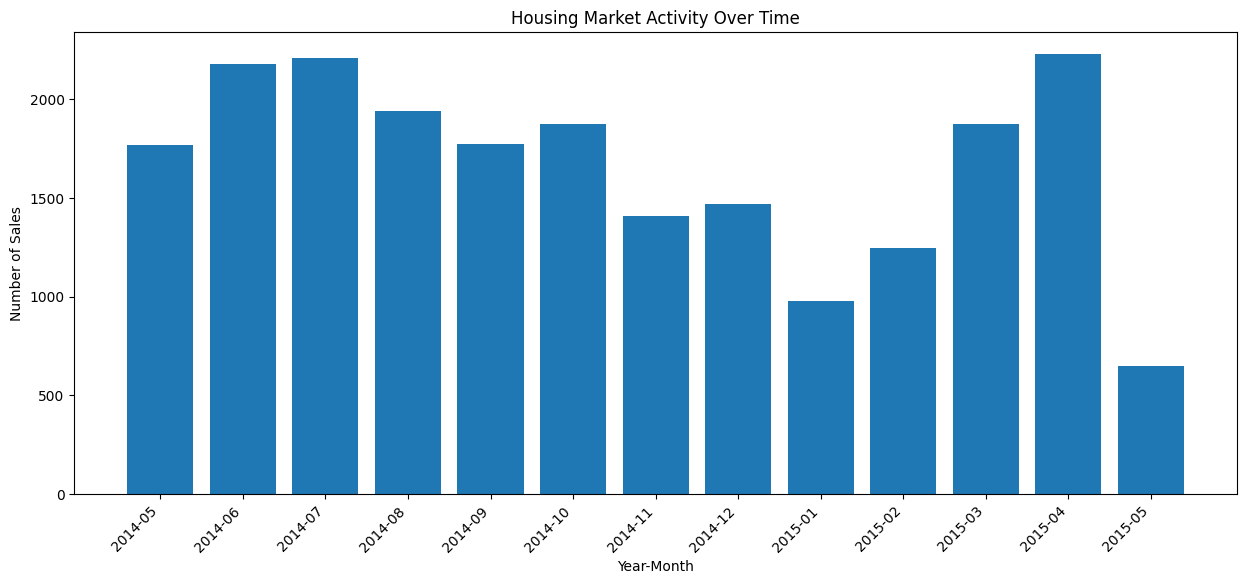

In [36]:
# Convert 'date' to datetime
df['date'] = pd.to_datetime(df['date'])

# Extract year-month
df['year_month'] = df['date'].dt.to_period('M')

# Count transactions per month
monthly_counts = df.groupby('year_month').size().reset_index(name='count')

# Plot
plt.figure(figsize=(15, 6))
plt.bar(monthly_counts['year_month'].astype(str), monthly_counts['count'])

plt.xlabel('Year-Month')
plt.ylabel('Number of Sales')
plt.title('Housing Market Activity Over Time')

plt.xticks(rotation=45, ha='right')
plt.show()

**Insight:** The distribution of transactions over time shows variations in market activity. Certain months have higher numbers of property sales, indicating periods of increased demand or market activity.

## Geographic Distribution of Prices

To better understand how location influences housing prices, I created a scatter plot of property locations, with each point color-coded based on price.

This allows for a visual comparison of price variations across different geographic areas.

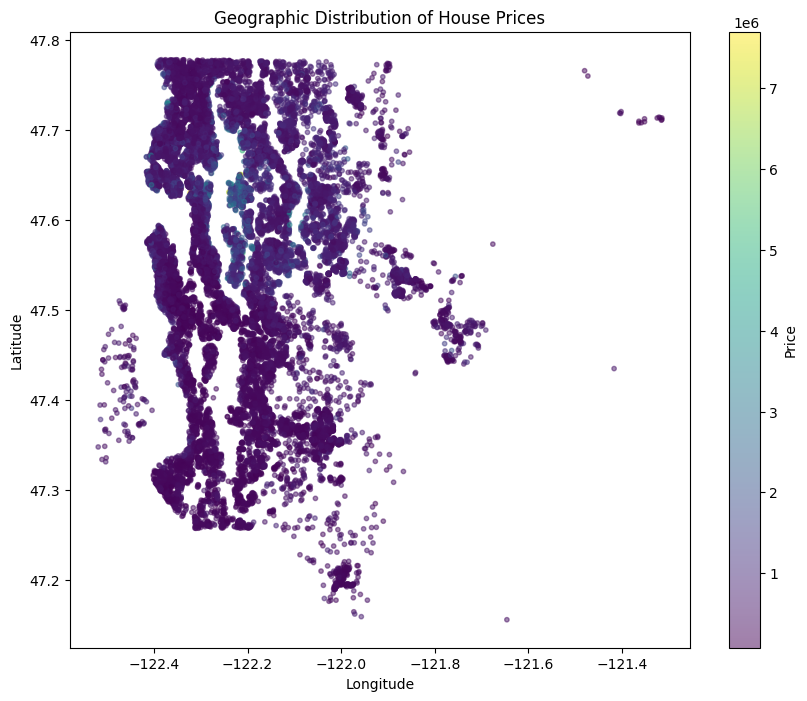

In [37]:
plt.figure(figsize=(10, 8))

plt.scatter(
    df['long'], 
    df['lat'], 
    c=df['price'], 
    cmap='viridis', 
    s=10, 
    alpha=0.5
)

plt.colorbar(label='Price')

plt.title('Geographic Distribution of House Prices')
plt.xlabel('Longitude')
plt.ylabel('Latitude')

plt.show()

**Key Insight:** Clusters of high-value properties likely correspond to desirable neighborhoods or waterfront areas, reinforcing earlier findings about the impact of location and amenities on property value.

## Monthly Average Sale Prices

To analyze overall price trends, I calculated the average house price for each month.

This provides a clearer view of general market behavior by reducing the impact of extreme high-value or low-value transactions.

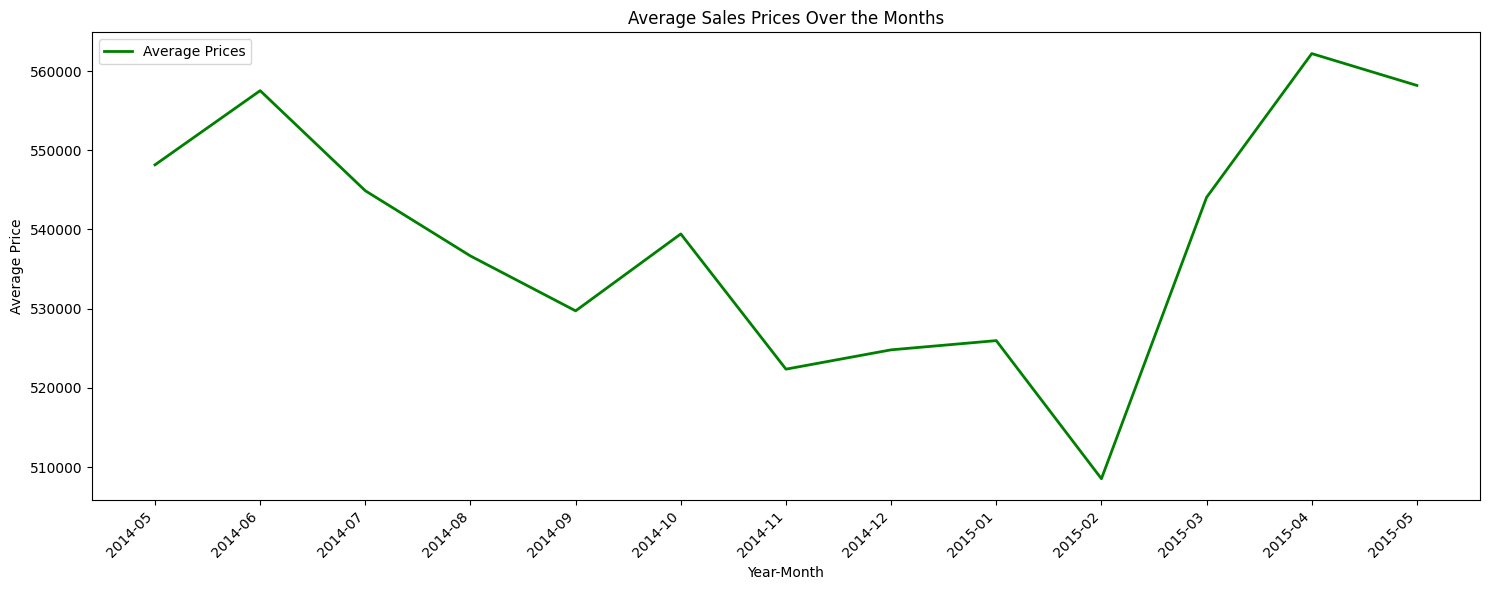

In [38]:
# Ensure datetime
df['date'] = pd.to_datetime(df['date'])

# Create year-month
df['year_month'] = df['date'].dt.to_period('M')

# Calculate monthly average prices
monthly_mean_prices = (
    df.groupby('year_month')['price']
    .mean()
    .reset_index()
)

# Plot
plt.figure(figsize=(15, 6))

plt.plot(
    monthly_mean_prices['year_month'].astype(str),
    monthly_mean_prices['price'],
    color='green',
    linewidth=2,
    label='Average Prices'
)

plt.xlabel('Year-Month')
plt.ylabel('Average Price')
plt.title('Average Sales Prices Over the Months')
plt.xticks(rotation=45, ha='right')
plt.legend()

plt.tight_layout()
plt.show()

**Insight:** The average price over time shows moderate fluctuations, suggesting that while individual transactions vary significantly, the overall market remains relatively stable.

This reinforces the importance of considering aggregated trends rather than individual sales.

## Waterfront Properties by Condition

To further explore premium properties, I analyzed how property condition affects prices among waterfront homes.

This helps identify whether better-maintained properties command higher prices within this high-value segment.

In [39]:
waterfront_df = df[df['waterfront'] == 1]

waterfront_df = waterfront_df.dropna(subset=['price', 'condition'])

In [40]:
waterfront_df.groupby('condition')['price'].mean()

condition
1    658000.000
2   2560000.000
3   1802661.875
4   1579260.870
5   1702022.222
Name: price, dtype: float64

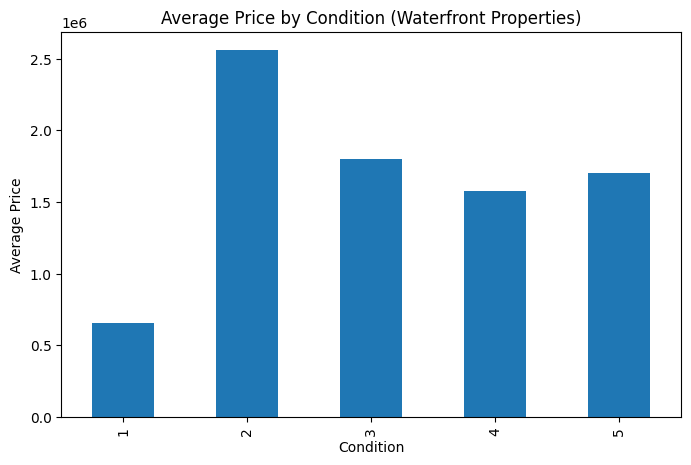

In [41]:
plt.figure(figsize=(8, 5))

waterfront_df.groupby('condition')['price'].mean().plot(kind='bar')

plt.title('Average Price by Condition (Waterfront Properties)')
plt.xlabel('Condition')
plt.ylabel('Average Price')

plt.show()

**Insight:** Waterfront properties with higher condition ratings tend to have higher average prices, suggesting that both location and property quality contribute to overall value.